# 第 2 节课 · Notebook 1：感知机（NumPy 手写版）

## 本 Notebook 目标

完成这个 Notebook 后，你将能够：
1. 解释什么是感知机，以及它和生物神经元的联系
2. 用 NumPy 从零实现一个感知机
3. 训练它学会 AND、OR 两个逻辑门
4. 理解为什么单层感知机学不会 XOR（异或）
5. 画出感知机的决策边界，直观理解「线性可分」

## 为什么从感知机开始？

深度学习里的神经网络，本质上就是很多「人工神经元」连接在一起。而**感知机（Perceptron）**就是最简单的人工神经元。理解了感知机，你就理解了神经网络最底层的运算单元。

感知机是 1957 年由 Frank Rosenblatt 提出的。虽然它很简单，但它奠定了现代神经网络的基础：
- 输入乘以权重，求和，加上偏置
- 通过激活函数得到输出
- 根据误差更新权重

今天我们会亲手写一个感知机，看着它学会 AND、OR，然后在 XOR 上失败。这个失败非常关键——它直接引出了「多层网络」的必要性。


## 0. 环境准备

本 Notebook 只需要两个基础库：
- **NumPy**：用于数值计算和矩阵运算
- **Matplotlib**：用于画图

如果你已经在本课程的 `dl-course` 环境中，这两个库应该已经安装好了。如果没有，可以用下面命令安装：

```bash
pip install numpy matplotlib
```

下面导入库并检查版本。


In [1]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体：让图表标题能正常显示中文
# 如果你的系统没有 SimHei 字体，可以改成 'Microsoft YaHei' 或直接注释掉
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print(f"NumPy 版本: {np.__version__}")
print("环境准备完成！")


NumPy 版本: 2.4.4
环境准备完成！


## 1. 感知机是什么？

### 1.1 从生物神经元到人工神经元

生物神经元的工作方式大致是这样的：
1. 树突接收来自其他神经元的信号
2. 细胞体把这些信号加权求和
3. 如果总和超过某个阈值，神经元就「兴奋」，通过轴突输出信号

人工神经元（感知机）借鉴了这个思想：
- **输入** $x_1, x_2, ..., x_n$：就像树突接收的信号
- **权重** $w_1, w_2, ..., w_n$：每个输入的重要性不同
- **偏置** $b$：决定神经元是否容易被激活
- **激活函数**：决定是否输出信号

### 1.2 感知机的数学模型

感知机的计算分为两步：

**第一步：加权求和（线性组合）**

$$z = w_1 x_1 + w_2 x_2 + ... + w_n x_n + b = \sum_{i=1}^{n} w_i x_i + b$$

用向量表示就是：

$$z = \mathbf{w}^T \mathbf{x} + b$$

**第二步：通过激活函数得到输出**

感知机最原始的激活函数是**阶跃函数（Step Function）**：

$$y = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z \leq 0 \end{cases}$$

也就是说：
- 如果加权求和 $z$ 大于 0，输出 1
- 否则输出 0

这是一个**二分类器**，只能把样本分成两类。

### 1.3 感知机如何学习？

感知机的学习规则（也叫**感知机学习规则**）是：

如果预测错了，就调整权重和偏置：

$$w_i = w_i + \eta \cdot (target - pred) \cdot x_i$$

$$b = b + \eta \cdot (target - pred)$$

其中：
- $target$ 是真实标签（0 或 1）
- $pred$ 是预测标签（0 或 1）
- $\eta$ 是**学习率**，控制每次更新的步长
- $target - pred$ 是误差：
  - 如果 $target=1, pred=0$，误差为 +1，要增大权重
  - 如果 $target=0, pred=1$，误差为 -1，要减小权重
  - 如果预测正确，误差为 0，不更新

这个规则非常直观：**如果预测错了，就让权重往正确方向移动一点**。


## 2. 用 NumPy 实现感知机

下面我们来写一个最简洁的感知机类。注意：**不调用任何深度学习框架**，只用 NumPy。

代码结构：
1. `__init__`：初始化权重、偏置、学习率、训练轮数
2. `forward`：给定输入，计算输出 0 或 1
3. `train`：遍历数据，根据误差更新权重
4. `predict`：对一组样本批量预测


In [2]:
class Perceptron:
    """
    用 NumPy 实现的二分类感知机。

    参数:
        input_dim: 输入特征的维度
        lr: 学习率 (learning rate)
        epochs: 训练轮数
    """
    def __init__(self, input_dim=2, lr=0.1, epochs=20):
        # 权重初始化为全 0
        # 对于感知机，0 初始化是可行的，因为数据对称
        self.weights = np.zeros(input_dim)
        # 偏置初始化为 0
        self.bias = 0.0
        # 学习率控制每次权重更新的步长
        self.lr = lr
        # 训练轮数
        self.epochs = epochs
        # 记录每一轮的准确率，方便后续画图
        self.history = []

    def forward(self, x):
        """
        前向传播：给定一个输入样本 x，计算输出 0 或 1。

        参数:
            x: 形状为 (input_dim,) 的 numpy 数组
        返回:
            0 或 1
        """
        # 第一步：加权求和 + 偏置
        z = np.dot(self.weights, x) + self.bias
        # 第二步：阶跃函数激活
        # 如果 z > 0 返回 1，否则返回 0
        return 1 if z > 0 else 0

    def train(self, X, y):
        """
        训练感知机。

        参数:
            X: 训练数据，形状为 (n_samples, input_dim)
            y: 训练标签，形状为 (n_samples,)，取值为 0 或 1
        """
        n = len(X)  # 样本数量

        # 外层循环：遍历 epochs 轮
        for epoch in range(self.epochs):
            correct = 0  # 记录本轮预测正确的数量

            # 内层循环：逐样本更新权重
            for xi, target in zip(X, y):
                # 前向传播，得到当前预测
                pred = self.forward(xi)

                # 计算误差：真实值 - 预测值
                error = target - pred

                # 根据感知机学习规则更新权重和偏置
                # 如果 error == 0，说明预测正确，权重不变
                # 如果 error == +1，说明预测为 0 但真实为 1，要增大权重
                # 如果 error == -1，说明预测为 1 但真实为 0，要减小权重
                self.weights += self.lr * error * xi
                self.bias += self.lr * error

                # 统计正确率
                if pred == target:
                    correct += 1

            # 计算本轮准确率
            acc = correct / n
            self.history.append(acc)

            # 打印前 5 轮和之后每 5 轮的训练状态
            if epoch < 5 or epoch % 5 == 0:
                print(f"Epoch {epoch:2d}: weights={self.weights.round(3)}, bias={self.bias:.3f}, acc={acc:.2%}")

    def predict(self, X):
        """
        对一组样本做预测。

        参数:
            X: 形状为 (n_samples, input_dim)
        返回:
            形状为 (n_samples,) 的预测标签
        """
        return np.array([self.forward(xi) for xi in X])


## 3. 任务一：训练感知机学会「与门」（AND）

AND 门的真值表：

| $x_1$ | $x_2$ | AND |
|:-----:|:-----:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 0 |
| 1 | 0 | 0 |
| 1 | 1 | 1 |

注意：AND 是**线性可分**的。我们可以用一条直线把输出为 1 的点 $(1,1)$ 和输出为 0 的其他三个点分开。

下面我们创建数据集并训练感知机。


In [3]:
# 定义 AND 门的数据集
# X 是输入，每一行是一个样本 [x1, x2]
X_and = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# y 是对应的输出
y_and = np.array([0, 0, 0, 1])

# 打印数据，方便对照真值表
print("AND 门训练数据：")
for xi, yi in zip(X_and, y_and):
    print(f"  {xi[0]} AND {xi[1]} = {yi}")

# 创建感知机实例
# input_dim=2 因为输入是二维的 [x1, x2]
# lr=0.1 学习率
# epochs=20 训练 20 轮
p_and = Perceptron(input_dim=2, lr=0.1, epochs=20)

# 训练感知机
print("\n开始训练...")
p_and.train(X_and, y_and)

# 训练完成后，对训练数据做预测，检查是否全部正确
preds = p_and.predict(X_and)
print(f"\n最终预测: {preds}")
print(f"真实标签: {y_and}")
print(f"准确率: {(preds == y_and).mean():.2%}")


AND 门训练数据：
  0 AND 0 = 0
  0 AND 1 = 0
  1 AND 0 = 0
  1 AND 1 = 1

开始训练...
Epoch  0: weights=[0.1 0.1], bias=0.100, acc=75.00%
Epoch  1: weights=[0.2 0.1], bias=0.000, acc=25.00%
Epoch  2: weights=[0.2 0.1], bias=-0.100, acc=25.00%
Epoch  3: weights=[0.2 0.2], bias=-0.100, acc=50.00%
Epoch  4: weights=[0.2 0.1], bias=-0.200, acc=75.00%
Epoch  5: weights=[0.2 0.1], bias=-0.200, acc=100.00%
Epoch 10: weights=[0.2 0.1], bias=-0.200, acc=100.00%
Epoch 15: weights=[0.2 0.1], bias=-0.200, acc=100.00%

最终预测: [0 0 0 1]
真实标签: [0 0 0 1]
准确率: 100.00%


### 结果分析

如果一切正常，你应该看到：
- 前几个 epoch，权重和偏置在快速变化
- 准确率逐渐上升
- 最终准确率达到 100%

这说明感知机成功地学会了 AND 门。

你可以思考一下：学到的权重 $w_1, w_2$ 和偏置 $b$ 具体是什么值？它们满足什么条件？

提示：对于 AND 门，需要满足：
- $w_1 \cdot 0 + w_2 \cdot 0 + b \leq 0$ → $b \leq 0$
- $w_1 \cdot 0 + w_2 \cdot 1 + b \leq 0$ → $w_2 + b \leq 0$
- $w_1 \cdot 1 + w_2 \cdot 0 + b \leq 0$ → $w_1 + b \leq 0$
- $w_1 \cdot 1 + w_2 \cdot 1 + b > 0$ → $w_1 + w_2 + b > 0$

例如 $w_1=0.5, w_2=0.5, b=-0.7$ 就满足这些条件。


## 4. 任务二：训练感知机学会「或门」（OR）

OR 门的真值表：

| $x_1$ | $x_2$ | OR |
|:-----:|:-----:|:--:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 1 |

OR 也是线性可分的。我们只需要把输出为 0 的点 $(0,0)$ 和输出为 1 的其他三个点分开。


In [4]:
# 定义 OR 门的数据集
X_or = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_or = np.array([0, 1, 1, 1])

print("OR 门训练数据：")
for xi, yi in zip(X_or, y_or):
    print(f"  {xi[0]} OR {xi[1]} = {yi}")

# 创建并训练感知机
p_or = Perceptron(input_dim=2, lr=0.1, epochs=20)
p_or.train(X_or, y_or)

# 预测并检查
preds = p_or.predict(X_or)
print(f"\n最终预测: {preds}")
print(f"真实标签: {y_or}")
print(f"准确率: {(preds == y_or).mean():.2%}")


OR 门训练数据：
  0 OR 0 = 0
  0 OR 1 = 1
  1 OR 0 = 1
  1 OR 1 = 1
Epoch  0: weights=[0.  0.1], bias=0.100, acc=75.00%
Epoch  1: weights=[0.1 0.1], bias=0.100, acc=50.00%
Epoch  2: weights=[0.1 0.1], bias=0.000, acc=75.00%
Epoch  3: weights=[0.1 0.1], bias=0.000, acc=100.00%
Epoch  4: weights=[0.1 0.1], bias=0.000, acc=100.00%
Epoch  5: weights=[0.1 0.1], bias=0.000, acc=100.00%
Epoch 10: weights=[0.1 0.1], bias=0.000, acc=100.00%
Epoch 15: weights=[0.1 0.1], bias=0.000, acc=100.00%

最终预测: [0 1 1 1]
真实标签: [0 1 1 1]
准确率: 100.00%


## 5. 可视化感知机的决策边界

感知机的输出由 $z = w_1 x_1 + w_2 x_2 + b$ 决定。

决策边界就是 $z = 0$ 的那条线：

$$w_1 x_1 + w_2 x_2 + b = 0$$

如果 $w_2 \neq 0$，我们可以解出：

$$x_2 = -\frac{w_1}{w_2} x_1 - \frac{b}{w_2}$$

这是一条直线。决策边界把平面分成两个区域：
- 直线上方（或一侧）：$z > 0$，预测为 1
- 直线下方（或另一侧）：$z \leq 0$，预测为 0

下面我们画出 AND 和 OR 的决策边界。


C:\Users\nan\AppData\Local\Temp\ipykernel_20336\1742573299.py:18: UserWarning: You passed an edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
findfont: Failed to find font weight bold, now using 400.


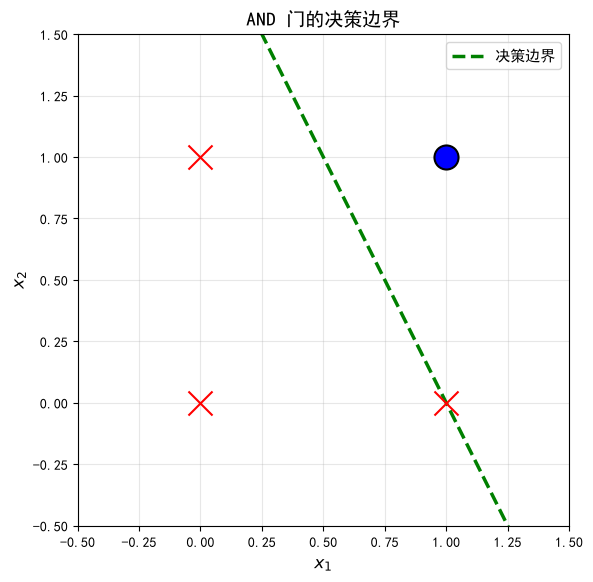

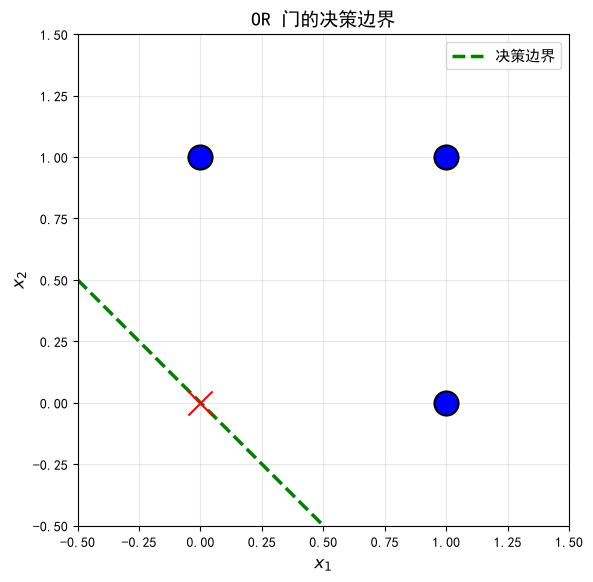

In [5]:
def plot_decision_boundary(model, X, y, title):
    """
    绘制感知机的决策边界和样本点。

    参数:
        model: 训练好的 Perceptron 实例
        X: 输入数据，形状 (n_samples, 2)
        y: 标签，取值为 0 或 1
        title: 图表标题
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    # 根据标签画样本点
    # 标签为 1 的用蓝色圆圈，标签为 0 的用红色叉号
    for xi, yi in zip(X, y):
        marker = 'o' if yi == 1 else 'x'
        color = 'blue' if yi == 1 else 'red'
        ax.scatter(
            xi[0], xi[1],
            marker=marker,
            s=300,                  # 点的大小
            c=color,
            edgecolors='black',     # 黑色边框
            linewidths=1.5,
            zorder=3                # 让点在最上层
        )

    # 画决策边界
    w1, w2 = model.weights
    b = model.bias

    # 在 x1 的范围 [-0.5, 1.5] 内取 100 个点
    x_vals = np.linspace(-0.5, 1.5, 100)

    # 如果 w2 接近 0，决策边界几乎是垂直线，避免除零
    if abs(w2) > 1e-6:
        # 根据 x2 = -(w1*x1 + b) / w2 计算对应的 x2
        y_vals = -(w1 * x_vals + b) / w2
        ax.plot(x_vals, y_vals, 'g--', linewidth=2.5, label='决策边界')

    # 设置坐标轴范围
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')  # 横纵坐标比例相同

    plt.tight_layout()
    plt.show()


# 画出 AND 和 OR 的决策边界
plot_decision_boundary(p_and, X_and, y_and, "AND 门的决策边界")
plot_decision_boundary(p_or, X_or, y_or, "OR 门的决策边界")


### 观察

从图中你可以看到：
- AND 门的决策边界成功把 $(1,1)$ 分到了 1 的区域
- OR 门的决策边界成功把 $(0,0)$ 分到了 0 的区域

这说明对于线性可分的问题，感知机可以找到一条合适的直线作为决策边界。


## 6. 任务三：感知机学不会「异或门」（XOR）

XOR 门的真值表：

| $x_1$ | $x_2$ | XOR |
|:-----:|:-----:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

把四个点画在平面上：
- $(0,0)$ 和 $(1,1)$ 输出 0
- $(0,1)$ 和 $(1,0)$ 输出 1

**你会发现，没有任何一条直线能把两个 0 和两个 1 分开！**

这就是**线性不可分**问题。感知机作为线性分类器，无法解决 XOR。

这个失败非常重要，它直接说明：
> 单层感知机的能力有限，我们需要多层网络才能解决非线性问题。


XOR 门训练数据：
  0 XOR 0 = 0
  0 XOR 1 = 1
  1 XOR 0 = 1
  1 XOR 1 = 0
Epoch  0: weights=[-0.1  0. ], bias=0.000, acc=50.00%
Epoch  1: weights=[-0.1  0. ], bias=0.100, acc=25.00%
Epoch  2: weights=[-0.1  0. ], bias=0.100, acc=0.00%
Epoch  3: weights=[-0.1  0. ], bias=0.100, acc=0.00%
Epoch  4: weights=[-0.1  0. ], bias=0.100, acc=0.00%
Epoch  5: weights=[-0.1  0. ], bias=0.100, acc=0.00%
Epoch 10: weights=[-0.1  0. ], bias=0.100, acc=0.00%
Epoch 15: weights=[-0.1  0. ], bias=0.100, acc=0.00%
Epoch 20: weights=[-0.1  0. ], bias=0.100, acc=0.00%
Epoch 25: weights=[-0.1  0. ], bias=0.100, acc=0.00%
Epoch 30: weights=[-0.1  0. ], bias=0.100, acc=0.00%
Epoch 35: weights=[-0.1  0. ], bias=0.100, acc=0.00%
Epoch 40: weights=[-0.1  0. ], bias=0.100, acc=0.00%
Epoch 45: weights=[-0.1  0. ], bias=0.100, acc=0.00%

最终预测: [1 1 0 0]
真实标签: [0 1 1 0]
准确率: 50.00%


C:\Users\nan\AppData\Local\Temp\ipykernel_20336\1742573299.py:18: UserWarning: You passed an edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\nan\AppData\Local\Temp\ipykernel_20336\1742573299.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=11)


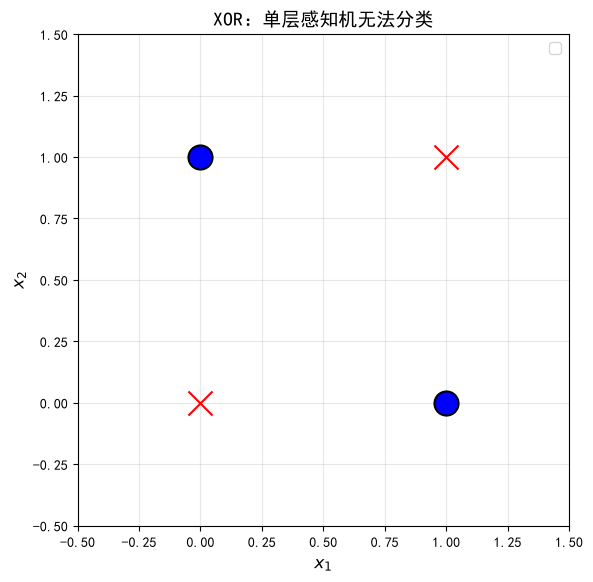

In [6]:
# 定义 XOR 门的数据集
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_xor = np.array([0, 1, 1, 0])

print("XOR 门训练数据：")
for xi, yi in zip(X_xor, y_xor):
    print(f"  {xi[0]} XOR {xi[1]} = {yi}")

# 创建并训练感知机，增加 epochs 看看能不能学会
p_xor = Perceptron(input_dim=2, lr=0.1, epochs=50)
p_xor.train(X_xor, y_xor)

# 预测并检查
preds = p_xor.predict(X_xor)
print(f"\n最终预测: {preds}")
print(f"真实标签: {y_xor}")
print(f"准确率: {(preds == y_xor).mean():.2%}")

# 画出决策边界
plot_decision_boundary(p_xor, X_xor, y_xor, "XOR：单层感知机无法分类")


### 结果分析

你很可能看到：
- 无论训练多少轮，准确率都在 50% 左右徘徊
- 决策边界是一条直线，无法把 $(0,1), (1,0)$ 和 $(0,0), (1,1)$ 同时分开

这就是感知机的根本局限：**它只能解决线性可分问题**。

### 如何解决 XOR？

有两种方法：

**方法 1：增加网络层数**

例如一个两层网络：
- 隐藏层神经元 1：学习 $x_1 \text{ AND } \neg x_2$
- 隐藏层神经元 2：学习 $\neg x_1 \text{ AND } x_2$
- 输出层：把上面两个结果做 OR

这样就用两层网络实现了 XOR。

**方法 2：使用非线性激活函数**

例如 Sigmoid、ReLU 等。非线性激活函数让网络可以拟合弯曲的决策边界。

这正是我们下一节要讲的 **MLP（多层感知机）** 的核心思想。


## 7. 动手练习

### 练习 1：改变学习率
把 AND 门的学习率分别改成 `0.01` 和 `0.5`，重新训练，观察：
- 收敛速度有什么变化？
- 学习率太大会不会导致震荡或不收敛？

### 练习 2：改变初始化
把权重初始化从 `np.zeros(input_dim)` 改成 `np.random.randn(input_dim) * 0.1`，对 AND/OR 的训练有影响吗？对 XOR 有影响吗？

### 练习 3（选做）：实现两层网络解决 XOR
提示：
- 隐藏层有 2 个神经元
- 输出层有 1 个神经元
- 使用 Sigmoid 激活函数
- 使用反向传播更新权重

如果你能实现这个，你就已经理解神经网络的核心原理了！


## 8. 常见问题

**Q1：为什么感知机的权重可以初始化为 0？**

A：对于感知机这种单层线性模型，0 初始化不会导致问题。但对于多层神经网络，0 初始化会让所有神经元学到同样的东西，所以需要随机初始化。

**Q2：感知机和逻辑回归有什么区别？**

A：感知机用阶跃函数做输出，只能输出 0 或 1；逻辑回归用 Sigmoid 函数，输出的是概率值。感知机是逻辑回归的「硬分类」版本。

**Q3：为什么 XOR 准确率停在 50%？**

A：因为感知机只能画直线。对于 XOR，无论怎么画直线，最多只能正确分类两个点，所以准确率上限是 50%。


## 9. 小结

- **感知机**是最简单的人工神经元：输入加权求和 + 阶跃函数
- **感知机学习规则**：预测错误时，按误差方向更新权重
- 感知机能解决 **AND、OR** 等线性可分问题
- 感知机**无法解决 XOR**，因为 XOR 是线性不可分的
- XOR 的失败引出了**多层网络 + 非线性激活函数**的必要性

下一节，我们将学习多层感知机（MLP），并用它解决更复杂的 MNIST 手写数字识别问题。
